In [57]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.radnav_stacked_pc_tb import RadnavStackedPCTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker


In [58]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
# folder_name = "WILK"
folder_name = "WILK_BASEMENT"
# file_name = "WILK_Multipath_Test_5" #for point cloud comparison (frame 1340)
# file_name = "WILK_Path_1_No_Dynamic"
file_name = "wilk_basement_2" #for point cloud processing (frame 780)

dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilk_basement_revB.yaml"#""wilkinson.yaml"
)

found 1396 radar samples
found 1396 lidar samples
found 1396 camera samples
found 1396 imu (orientation only) samples
found 1396imu (full data) samples
found 1396 vehicle velocity samples
loaded map from /data/radnav/maps/wilk_basement_revB.yaml
loaded map free space from /data/radnav/maps/wilk_basement_revB.yaml


In [59]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,#originally 0.1
    icp_best_points_percentile=80, #originally 65 ->80
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

In [60]:
#initialize the point cloud stacker
pc_stacker = temporalPcStacker(
    num_frames_static_history = 4, # originally 4
    num_frames_dynamic_history = 0, # originally 0
    refresh_distance_m = 3, #originally 3
    refresh_rot_deg = 90, #originally 90
    refresh_time_s = 5, #originally 5
    grid_resolution_m = 5e-2, #originally 5e-2
    grid_max_distance_m = 20, #originally 20
    multi_path_clustering_eps = 0.5, #originally 0.5
    multi_path_clustering_min_samples = 15,  #originally 15
    multi_path_num_frames_history=4, # originally 4
    vel_filtering_enabled = True,
    vel_filtering_v_thresh = 0.05, # originally 0.05
    vel_filtering_min_static_rejection_radius = 0.25, #originally 0.25
    vel_filtering_dynamic_cluster_eps = 0.5, #originally 0.5
    vel_filtering_dynamic_cluster_min_samples = 15, #originally 15
    min_detection_radius_m=1.5, #originally 1.5
    max_detection_range_m=20, #originally 20
    gyro_bias=-0.0024 #originally -0.0024
)

loaded map with 19375 points
loaded map with 19375 points
gt icp estimated heading:-3.0379008574268815 deg, pose:[0.07976698 0.11528889]


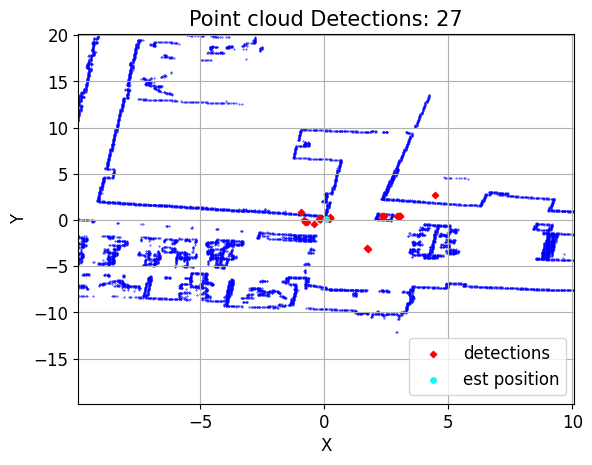

In [61]:
test_bench = RadnavStackedPCTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    pc_stacker=pc_stacker
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024 #originally -0.0024
)

#initialize the point cloud stacker
test_bench.init_pc_stacker(
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


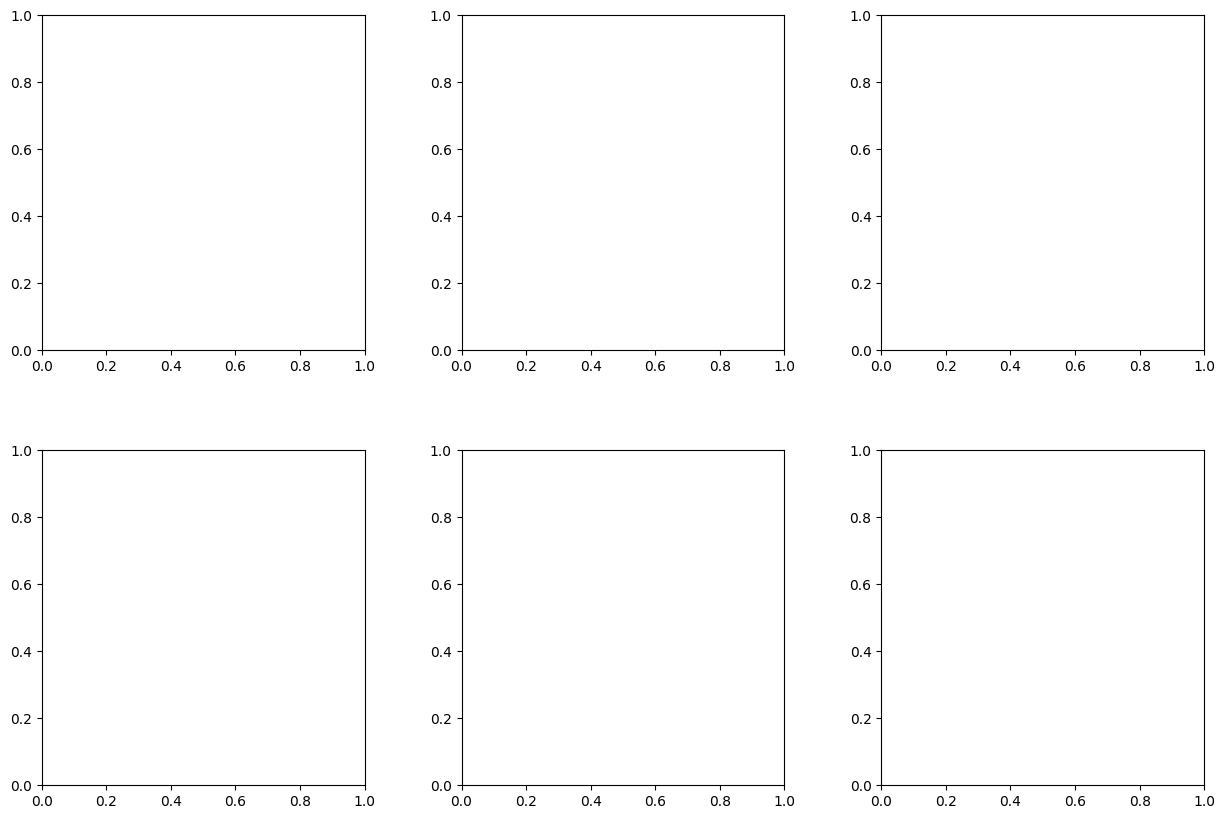

In [62]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [63]:
end_idx = 780#dataset.num_frames #point cloud sample: frame 1340 on Wilk_Multipath_test_5
save_name = file_name + "radar_combined"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False,
    movie_generator=None)

#run to around 1:07 mark for looking at the point cloud

100%|██████████| 780/780 [00:02<00:00, 335.61it/s]


In [64]:
np.save("Trajectories/gt.npy",test_bench.history_position_m_gt)
np.save("Trajectories/radnav.npy",test_bench.history_position_m)

In [65]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

0it [00:00, ?it/s]


In [66]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=file_name,
    export_to_csv=False
)

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

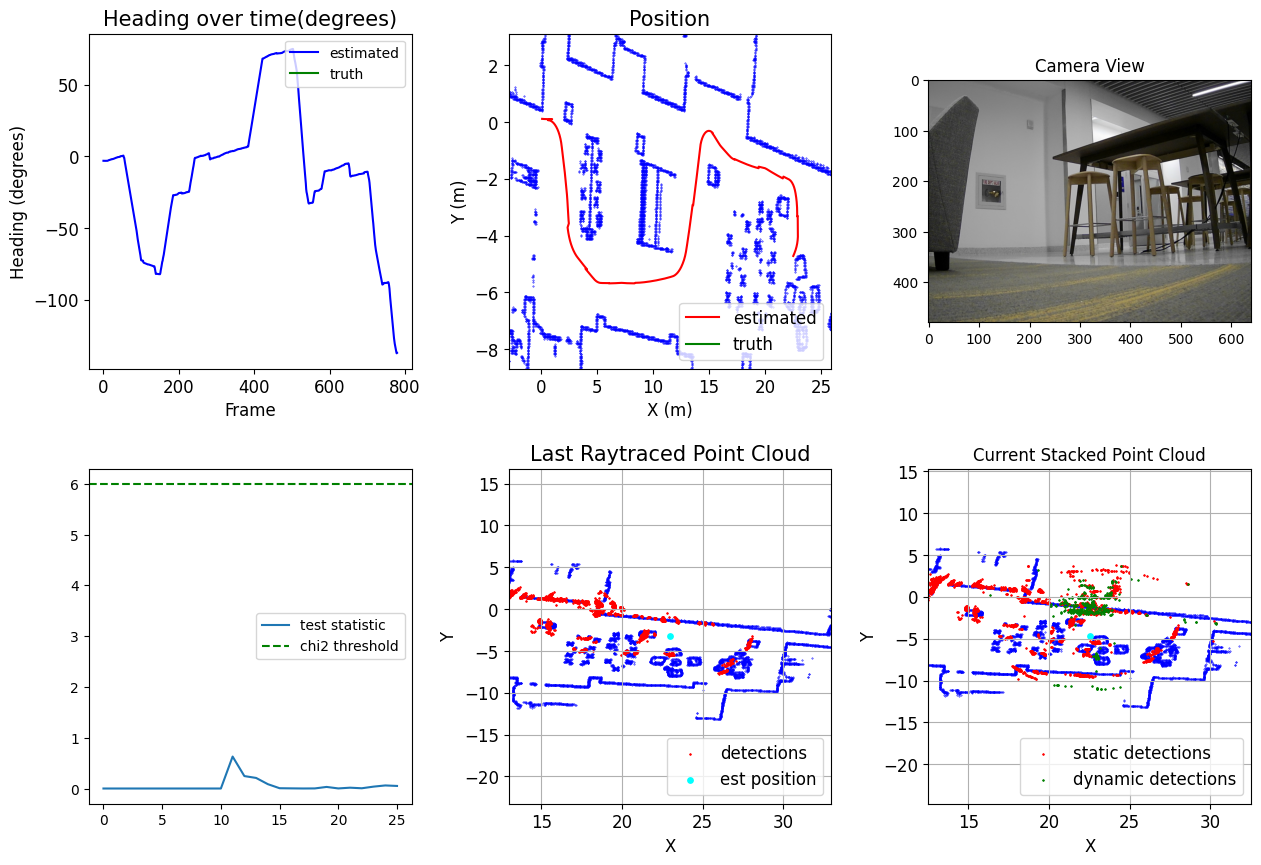

In [ ]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

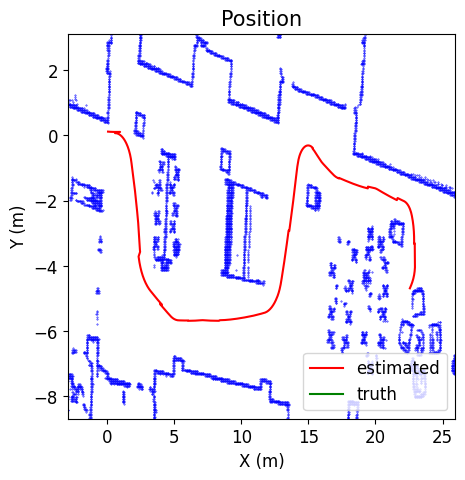

In [ ]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

# fig.savefig("Images/position_history/{}.png".format(save_name))

In [ ]:
print(test_bench.filter.x[0:3])
print(test_bench.gt_localizer.current_pose_m)
print(test_bench.point_cloud_stacker.integrator.x[0:3])
print(test_bench.point_cloud_stacker.initial_pose_m)
print(test_bench.point_cloud_stacker.current_pose_m)
print(np.linalg.norm(test_bench.gt_localizer.current_pose_m - test_bench.filter.x[0:2]))

In [ ]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

['map', 'static detections', 'dynamic detections', 'est position']


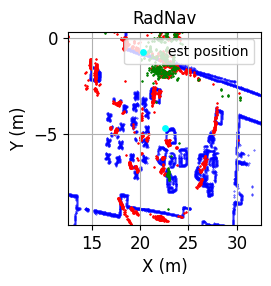

In [ ]:
#visualizing the point cloud - for point cloud comparison
fig, axs = plt.subplots(figsize=(2.5,2.5))

combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
dynamic_combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_dynamic()

test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_pc,
    dynamic_points=dynamic_combined_pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=axs,

    show=False
) 
axs.set_title("RadNav",
                fontsize=test_bench.plotter_localization.font_size_legend)
axs.set_xlim(
    test_bench.filter.x[0] - 10,
    test_bench.filter.x[0] + 10)
axs.set_xlabel("X (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
axs.set_ylim(
    test_bench.filter.x[1] - 5,
    test_bench.filter.x[1] + 5)
axs.set_ylabel("Y (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
handles,labels = axs.get_legend_handles_labels()
print(labels)
axs.legend(handles[3:4], labels[3:4], loc="upper right",fontsize=10)

plt.show()

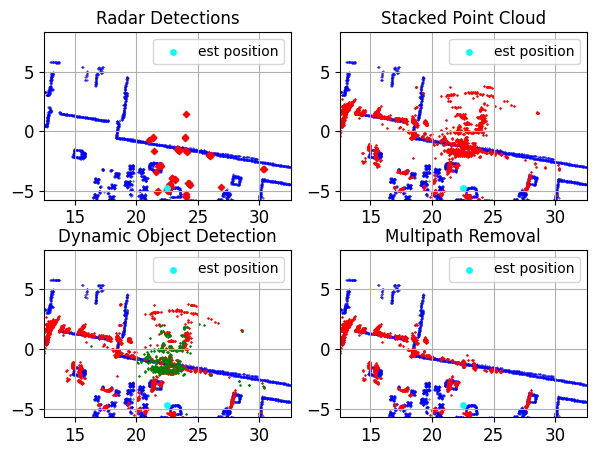

In [67]:
#visualizing the point cloud - for processing visualization
fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(7,5))
plt.subplots_adjust(hspace=0.3)
#top left - single radar point cloud
ax=axs[0,0]
pc = dataset.get_radar_detections(idx=end_idx)[:,0:2]
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
)
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Radar Detections",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - stacked point cloud
ax=axs[0,1]
combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
dynamic_combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_dynamic()
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=np.append(combined_pc,dynamic_combined_pc,axis=0),
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Stacked Point Cloud",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - velocities filtered
ax=axs[1,0]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_pc,
    dynamic_points=dynamic_combined_pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[3:4], labels[3:4], loc="upper right",fontsize=10)
ax.set_title("Dynamic Object Detection",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom right - final point cloud
test_bench.point_cloud_stacker.refresh()
pc = test_bench.point_cloud_stacker.get_latest_pc()
ax=axs[1,1]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Multipath Removal",
                fontsize=test_bench.plotter_localization.font_size_legend)

for r in range(2):
    for c in range(2):
        axs[r,c].set_xlim(
            test_bench.filter.x[0] - 10,
            test_bench.filter.x[0] + 10)
        axs[r,c].set_xlabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)
        axs[r,c].set_ylim(
            test_bench.filter.x[1] - 1,
            test_bench.filter.x[1] + 13)
        axs[r,c].set_ylabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)

plt.show()

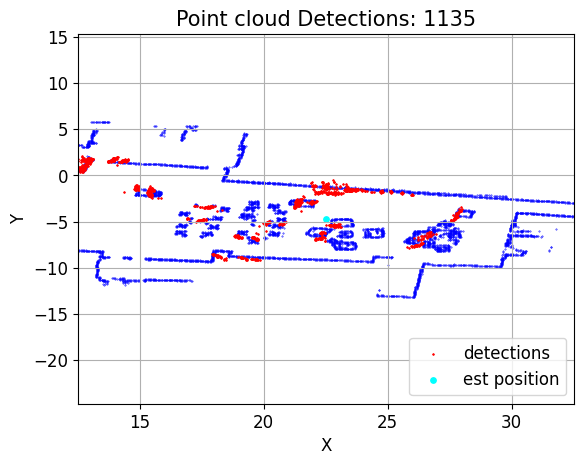

In [11]:
#visualizing the point cloud
pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

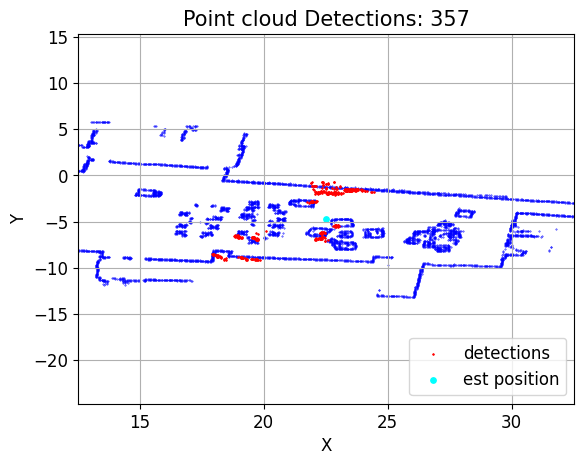

In [12]:
#debugging temporal pc stack
pc_grid = test_bench.point_cloud_stacker.pc_grid_static[0:1]
pc = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid)
pc = test_bench.point_cloud_stacker._change_pc_reference_frame(
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m,
    current_points=pc
)
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)


test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



In [ ]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)


In [ ]:
from tqdm import tqdm

r = int(len(test_bench.history_pc_stacker_point_clouds)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
# fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

In [ ]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

## Debugging (testing ray tracing)

In [13]:
#timing analysis
pc_grid_static_orig = test_bench.point_cloud_stacker.pc_grid_static.copy()
pc_grid_dynamic_orig = test_bench.point_cloud_stacker.pc_grid_dynamic.copy()

for i in tqdm(range(500)):

    test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
    test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

    test_bench.point_cloud_stacker.refresh()

#reset the point cloud stacker:
test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

100%|██████████| 500/500 [00:20<00:00, 23.86it/s]


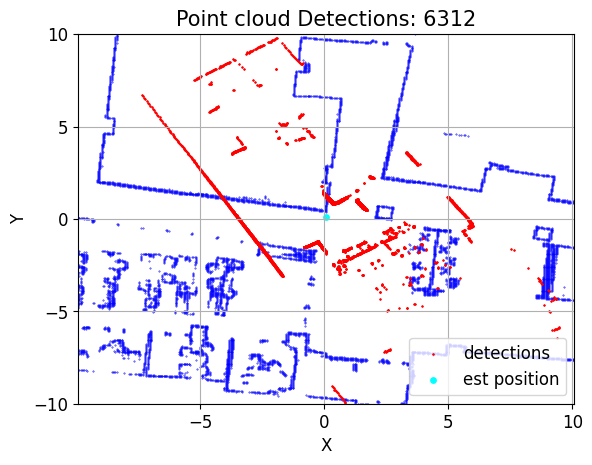

In [14]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

0.0
0.0


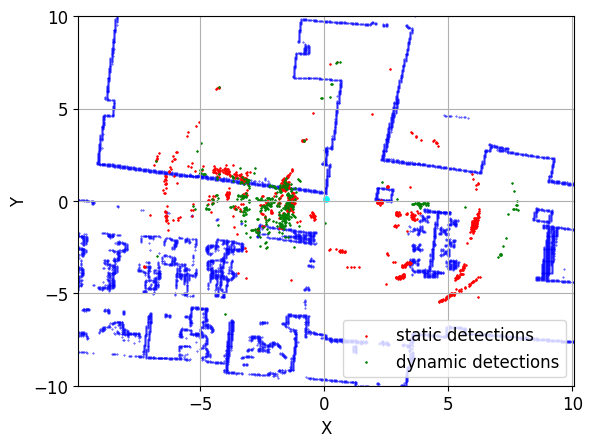

In [15]:
#recenter the point cloud grids
pc_grids_static = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_static,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)

pc_grid_dynamic = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_dynamic,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)


current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grids_static[0:1])
dynamic_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid_dynamic)

print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=current_points,
    dynamic_points = dynamic_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = \
    test_bench.point_cloud_stacker.vel_filtering.remove_dynamic_clusters_from_static_detections_knn(
        current_points,
        dynamic_points
    )

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#perform current multi-path
multipath_num_frames_history = 2

#update the static point grid
pc_grids_static[0] = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static[0:multipath_num_frames_history+1])

labels = test_bench.point_cloud_stacker.multi_path._cluster_points(current_points)

fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=current_points,
    labels=labels,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)


ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = test_bench.point_cloud_stacker.multi_path.remove_multipath(
    pc_cartesian=current_points
)

grid = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
pc_grids_static[0] = np.logical_and(grid,pc_grids_static[0])

current_points = test_bench.point_cloud_stacker._get_points_from_pc_grid(pc_grids_static[0])

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    valid_stacked_pc_cart = test_bench.point_cloud_stacker.multi_path.remove_multipath(current_points)

### Debugging ICP

In [ ]:
#get the point cloud (from the previous step)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static
)
# plot the point cloud before icp
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.filter.x[2],
    pose_m= test_bench.filter.x[0:2],
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#configure icp for only a single update
test_bench.localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.localizer.update_odometry(
        points=current_points,
        estimated_heading_rad=test_bench.filter.x[2],
        estimated_pose_m=test_bench.filter.x[0:2]
    )

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

### Evaluating processing time for lidar localization

In [ ]:
pc = dataset.get_lidar_point_cloud(idx=end_idx-1)

#configure icp for only a single update
test_bench.gt_localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.gt_localizer.update_odometry(
        points=pc[:,0:2],
        estimated_heading_rad=test_bench.filter_gt.x[2],
        estimated_pose_m=test_bench.filter_gt.x[0:2]
    )
print(pc.shape[0])